# 02: Volt-Watt and Volt-VAr conformance and curtailment

This notebook keeps three questions separate: **maximum-output or required-Q conformance**, **whether the observation was informative about an active response**, and **counterfactual-supported curtailed energy**. 

The 10% site threshold is a project reporting convention, not a tolerance granted by AS/NZS 4777.2.

## Interpretation contract

- Volt-Watt conformance asks whether measured P exceeded the voltage-dependent maximum. It does not require a counterfactual.
- Volt-Watt response support asks whether measured P already proved a violation or the counterfactual showed enough solar resource to test the response.
- Curtailment energy is calculated only on intervals with a counterfactual. Missing counterfactuals are reported, never replaced with zero.
- Volt-VAr conformance uses the Stage 2 capability-assessable denominator. Low-power intervals excluded by Section 2.6 (Figure 2.1) of AS/NZ 4777.2.2020 implementation are reported separately.

In [2]:
%matplotlib inline

import importlib
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# Locate the repository.
HERE = Path.cwd().resolve()

REPO_ROOT = next(
    (
        path
        for path in (HERE, *HERE.parents)
        if (path / "bms_sa_review").is_dir()
    ),
    None,
)

if REPO_ROOT is None:
    raise RuntimeError(
        "Cannot find the repository root containing bms_sa_review. "
        f"Current directory: {HERE}"
    )


# Expose all import styles currently used in the repository.
PACKAGE_ROOT = REPO_ROOT / "bms_sa_review"
SHARED = PACKAGE_ROOT / "shared"
LIB = PACKAGE_ROOT / "data_query" / "lib"

for path in (REPO_ROOT, PACKAGE_ROOT, SHARED, LIB):
    path_string = str(path)

    if path_string not in sys.path:
        sys.path.insert(0, path_string)


# Project imports.
from bms_sa_review.shared.aws_config import aq

import analysis_contract as contract
import conformance_queries as cq
import conformance_metrics as cm
import conformance_plots as cp


# Reload local analytical modules during notebook development.
for module in (contract, cq, cm, cp):
    importlib.reload(module)


pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

print("Repository root:", REPO_ROOT)
print("Package root:", PACKAGE_ROOT)
print("Shared modules:", SHARED)
print("Analysis library:", LIB)

Repository root: C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA
Package root: C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\bms_sa_review
Shared modules: C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\bms_sa_review\shared
Analysis library: C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\bms_sa_review\data_query\lib


In [3]:
CONFIG = contract.AnalysisConfig(
    years=(2024, 2025),
    flex_selection='exclude',
    rating_basis='ac_capacity_kw',
    empirical_limit_basis='s_99',
    voltage_aggregation='avg',
    capability_profile='review_corrected',
    day_night='all',
    min_site_intervals=1,
).validate()
display(contract.manifest(CONFIG))

,setting,value
0,database,solar_analytics_iceberg
1,years,"2024, 2025"
2,interval_minutes,5.0
3,site_nonconf_threshold,0.1
4,minimum_site_intervals,1
5,flex_selection,exclude
6,rating_basis,ac_capacity_kw
7,empirical_limit_basis,s_99
8,voltage_aggregation,avg
9,capability_profile,review_corrected


## 1. Inputs, stored provenance, and metadata integrity

In [4]:
inventory = cq.fetch_inventory(aq, CONFIG)
stored_provenance = cq.fetch_stored_provenance(aq, CONFIG)
display(inventory)
display(stored_provenance)

meta = cq.fetch_metadata(aq, CONFIG)
meta_conflicts = cm.validate_metadata(meta)
display(meta_conflicts)
assert not meta['site_id'].duplicated().any()

,logical_name,table_name,n_rows,n_sites,first_year,last_year
0,structured_data,structured_data_v2,841491009,15454,2024,2025
1,all_uncurtailedpv,all_uncurtailedpv_v2,487222740,15308,2024,2025
2,conformance_voltvar,conformance_voltvar_v2,15101224,15609,2024,2025
3,conformance_voltwatt,conformance_voltwatt_v2,15101224,15609,2024,2025
4,conformance_voltwattghi,conformance_voltwattghi_v2,15101224,15609,2024,2025


,table_name,normalization_basis,voltage_aggregation,flex_selection,n_rows,counterfactual_cap_basis,rating_basis,empirical_limit_basis,capability_profile
0,structured_data_v2,s_99,avg,exclude,841491009,<NA>,<NA>,<NA>,<NA>
1,all_uncurtailedpv_v2,s_99,<NA>,<NA>,487222740,none,<NA>,<NA>,<NA>
2,conformance_voltwatt_v2,<NA>,avg,exclude,15101224,<NA>,ac_capacity_kw,<NA>,<NA>
3,conformance_voltwattghi_v2,<NA>,avg,exclude,15101224,<NA>,ac_capacity_kw,<NA>,<NA>
4,conformance_voltvar_v2,<NA>,avg,exclude,15101224,<NA>,ac_capacity_kw,s_99,review_corrected


,field,sites_with_multiple_values
0,n_state_values,0
1,n_dnsp_values,0
2,n_oem_values,0
3,n_ac_capacity_values,0
4,n_s99_values,0


In [5]:
population_funnel = cq.fetch_population_funnel(aq, CONFIG)
display(population_funnel.T.rename(columns={0: 'n_sites'}))

,n_sites
sites_in_stage2,15609
vw_voltage_exposed_sites,4809
vw_counterfactual_present_sites,3500
vw_response_supported_sites,1878
vw_sites_with_missing_counterfactual,4363
vv_voltage_exposed_sites,15540
vv_capability_assessable_sites,15609
vv_apparent_limit_symptom_sites,7238


## 2. Volt-Watt maximum-output conformance

**Question:** when voltage selected a reduced maximum active-power level, did measured P exceed that permitted maximum (including the stored ±4% band)? A below-ceiling observation satisfies this maximum-output test but does not, by itself, demonstrate active curtailment.

In [16]:
#### Parameters presented below ####
# n_sites = The number of distinct sites with at least one evaluated Volt-Watt interval.
# n_intervals = The total number of five-minute site intervals where *average* site voltage was greater than 253 V.
# n_nonconforming_intervals = The number of voltage-exposed intervals where measured active power exceeded the permitted Volt-Watt maximum: P_measured > P_VW_curve(V) + 0.04 × ac_capacity_kw
# interval_nonconf_pct = 100 × n_nonconforming_intervals / n_intervals

#### Agreggations ####
# fleet_conformant_pct:
## First, a nonconformance fraction is calculated separately for each site: site nonconformance fraction = site nonconforming intervals / site exposed intervals
## The project rule then classifies a site as conformant when: site nonconformance fraction <= 10%
## fleet_conformant_pct is the percentage of evaluated sites satisfying that rule: fleet_conformant_pct = 100 × conformant sites / evaluated sites

# fleet_any_nonconf_pct
## The percentage of evaluated sites with at least one nonconforming interval:
## fleet_any_nonconf_pct = 100 × sites with at least one nonconforming interval / evaluated sites

In [6]:
vw_site_year = cq.fetch_vw_site_year(aq, CONFIG)
vw_sites = cm.prepare_vw_conformance(vw_site_year, CONFIG)
vw_result = cm.fleet_result(
    vw_sites, 'Volt-Watt maximum-output conformance',
    'Did measured P exceed the voltage-dependent maximum?',
    'voltage-exposed intervals (V > 253 V)',
)
display(vw_result)
display(vw_sites.sort_values('nonconf_frac', ascending=False).head(20))

,metric,question,denominator,n_sites,n_intervals,n_nonconforming_intervals,interval_nonconf_pct,fleet_conformant_pct,fleet_any_nonconf_pct
0,Volt-Watt maximum-output conformance,Did measured P exceed the voltage-dependent ma...,voltage-exposed intervals (V > 253 V),4809,6571925,868083,13.208961,84.903306,28.259513


,site_id,all_intervals_count,exposed_count,nonconf_count,nonconf_kw_sum,denominator_count,nonconf_frac,conformant,nonconformant,any_nonconformance
111,14582897,207009,1,1,4.487190,1,1.0,False,True,True
143,18281570,52463,1,1,2.194636,1,1.0,False,True,True
10186,1411723533,205896,1,1,5.016560,1,1.0,False,True,True
9964,1379469053,207924,1,1,0.171917,1,1.0,False,True,True
9931,1374027046,208055,1,1,3.724480,1,1.0,False,True,True
10622,1470007742,160808,1,1,1.555090,1,1.0,False,True,True
10531,1456940621,162380,1,1,5.358330,1,1.0,False,True,True
10462,1448755647,161515,1,1,6.021460,1,1.0,False,True,True
9899,1370153926,18108,1,1,0.293906,1,1.0,False,True,True
9583,1326518094,207942,2,2,4.421827,2,1.0,False,True,True


## 3. Volt-Watt response support and counterfactual coverage

This is a narrower evidentiary population, not a replacement compliance population. An interval is response-supported when actual P proves a violation or the counterfactual exceeds the permitted maximum.

In [ ]:
#### Parameters presented below ####

# exposed_intervals = All five-minute intervals where average site voltage was greater than 253 V

# response_supported_intervals:
## An exposed interval is response-supported when either:
## measured P exceeded the permitted Volt-Watt maximum, establishing a definite violation; or
## counterfactual P exceeded the permitted maximum, showing that sufficient solar power was available to test the response.

# missing_counterfactual_intervals = The number of voltage-exposed intervals for which all_uncurtailedpv_v2 supplied no matching counterfactual estimate

# response_supported_pct_of_exposed = 100 × response-supported intervals / exposed intervals
# missing_counterfactual_pct_of_exposed = 100 × missing-counterfactual intervals / exposed intervals 

#### Aggregations ####
# interval_nonconf_pct = 100 × nonconforming intervals / response-supported intervals
### This is not be presented as the fleet-wide Volt-Watt nonconformance rate.
### It is high because:
### - every measured violation enters the response-supported population;
### - a below-limit observation enters only when the counterfactual proves that enough solar power was available to test the response. 

# fleet_conformant_pct:
## For each response-supported site:
## site response-supported nonconformance fraction = site nonconforming intervals / site response-supported intervals
## The same project threshold is then applied:
## conformant if site fraction <= 10% 
## (This is not the primary fleet conformance result. It is a narrower result among sites where at least one informative response verdict was available.)

# fleet_any_nonconf_pct
## The percentage of response-supported sites with at least one directly observed violation:
## fleet_any_nonconf_pct = 100 × response-supported sites with any violation / all response-supported sites

In [7]:
vwg_site_year = cq.fetch_vw_response_site_year(aq, CONFIG)
vwg_sites = cm.prepare_vw_response(vwg_site_year, CONFIG)
vwg_result = cm.fleet_result(
    vwg_sites, 'Volt-Watt response-supported result',
    'Was enough solar power available to test the response, or was a violation directly observed?',
    'response-supported intervals',
)
display(cm.coverage_summary(vwg_site_year))
display(vwg_result)
membership = vw_sites[['site_id']].merge(vwg_sites[['site_id']], on='site_id', how='outer', indicator=True)
display(membership['_merge'].value_counts().rename_axis('membership').to_frame('n_sites'))

,exposed_intervals,response_supported_intervals,missing_counterfactual_intervals,response_supported_pct_of_exposed,missing_counterfactual_pct_of_exposed
0,6571925,944752,4065756,14.375575,61.865526


,metric,question,denominator,n_sites,n_intervals,n_nonconforming_intervals,interval_nonconf_pct,fleet_conformant_pct,fleet_any_nonconf_pct
0,Volt-Watt response-supported result,Was enough solar power available to test the r...,response-supported intervals,1878,944752,868083,91.884749,32.00213,72.364217


,n_sites
membership,
left_only,2931
both,1878
right_only,0


,minimum_intervals,n_sites,fleet_conformant_pct,median_nonconf_frac
0,1,4809,84.903306,0.000000
1,5,3637,85.949959,0.000000
2,10,3199,85.589247,0.000000
3,30,2675,83.925234,0.000000
4,100,2006,81.455633,0.000000
5,300,1454,78.610729,0.000074


,minimum_intervals,n_sites,fleet_conformant_pct,median_nonconf_frac
0,1,1878,32.002130,0.950096
1,5,1099,29.845314,0.906250
2,10,932,27.253219,0.927051
3,30,673,22.436850,0.949602
4,100,443,13.544018,0.961210
5,300,293,6.143345,0.968069


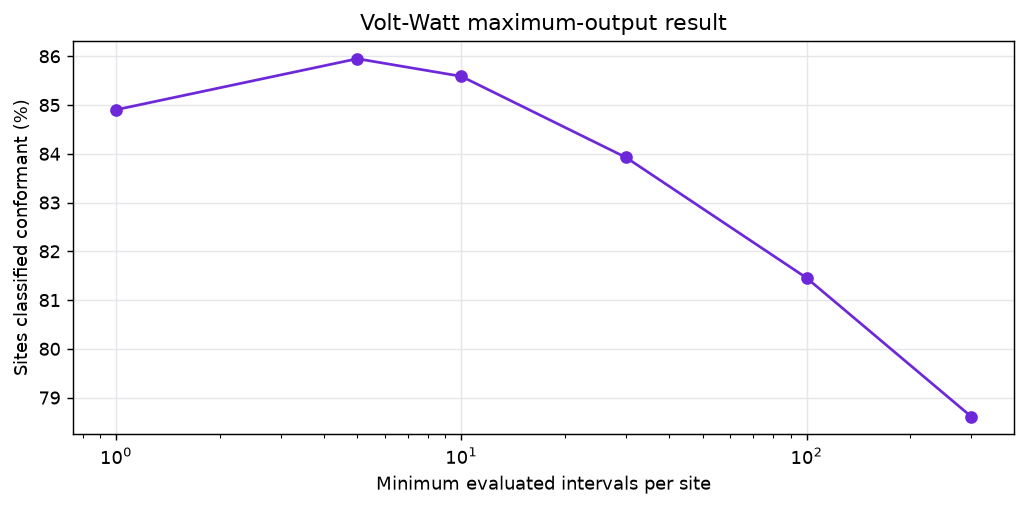

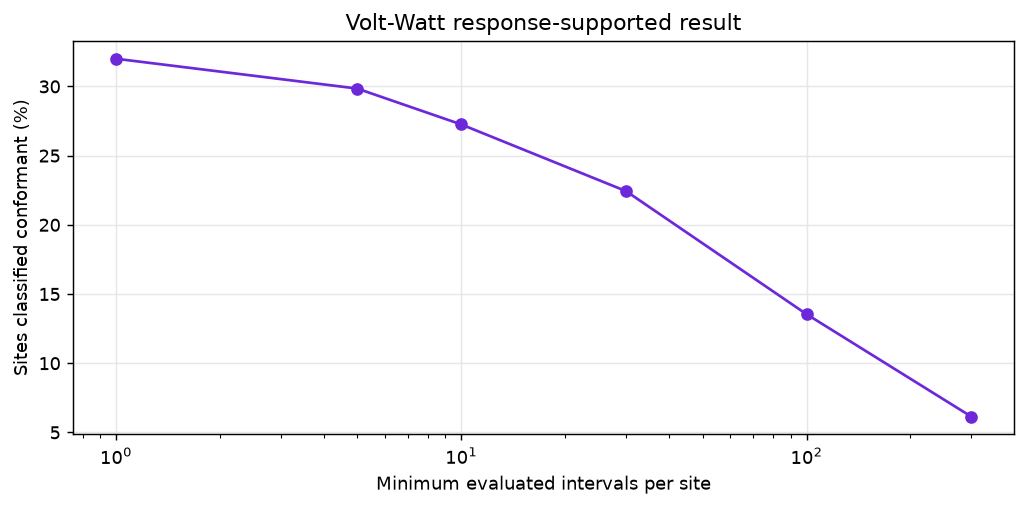

In [ ]:
vw_sensitivity = cm.minimum_interval_sensitivity(
    vw_site_year, 'nonconf_count', 'exposed_count', CONFIG)
vwg_sensitivity = cm.minimum_interval_sensitivity(
    vwg_site_year, 'nonconf_count', 'response_supported_count', CONFIG)
display(vw_sensitivity)
display(vwg_sensitivity)
cp.plot_sensitivity(vw_sensitivity, 'Volt-Watt maximum-output result')
cp.plot_sensitivity(vwg_sensitivity, 'Volt-Watt response-supported result')

## 4. Volt-Watt curtailed energy

Energy is reported only for counterfactual-covered intervals where potential P exceeded the permitted maximum and measured P did not. Five-minute kW samples are multiplied by 1/12 to obtain kWh.

In [9]:
vw_energy_site_year = cq.fetch_vw_energy_site_year(aq, CONFIG)
vw_energy_sites, vw_energy_summary = cm.energy_summary(
    vw_energy_site_year, CONFIG.interval_h, 'Volt-Watt counterfactual curtailment')
display(vw_energy_summary)
display(vw_energy_sites.sort_values('curtailed_kwh', ascending=False).head(20))

,metric,year,n_sites,n_intervals,curtailed_kwh,counterfactual_generation_kwh,curtailed_pct_of_counterfactual
0,Volt-Watt counterfactual curtailment,2024,940,41853,4646.429809,22630.571604,20.531650
1,Volt-Watt counterfactual curtailment,2025,755,34816,3537.847467,19136.816211,18.487127


,site_id,year,curtailed_count,curtailed_kw_sum,measured_kw_sum,potential_kw_sum,curtailed_kwh,measured_kwh,potential_kwh
1643,449516314,2024,377,2703.341142,6145.418543,8848.759685,225.278429,512.118212,737.396640
1543,1837079785,2024,1177,2121.673739,8088.188792,10209.862531,176.806145,674.015733,850.821878
493,449516314,2025,354,2088.388149,6620.495183,8708.883332,174.032346,551.707932,725.740278
713,814602644,2024,904,2073.623537,6111.193228,8184.816765,172.801961,509.266102,682.068064
1624,284910195,2025,1435,1795.788686,8817.995100,10613.783786,149.649057,734.832925,884.481982
440,465008538,2024,795,1508.988593,2675.534100,4184.522693,125.749049,222.961175,348.710224
878,1302917070,2024,540,1453.950103,1598.396363,3052.346466,121.162509,133.199697,254.362205
1456,1588083868,2024,600,1257.976862,1478.262763,2736.239625,104.831405,123.188564,228.019969
322,1800975821,2024,587,1236.915417,980.948507,2217.863923,103.076285,81.745709,184.821994
1575,755163749,2024,518,1219.370637,2943.809386,4163.180023,101.614220,245.317449,346.931669


## 5. Volt-VAr conformance

**Question:** among intervals where the selected Figure 2.1 capability implementation provides a quantified minimum, was measured Q within the required/capability-clamped band? The project failure definition is adverse + inactive + significant shortfall. Near-conformant and surplus are shown separately.

,metric,question,denominator,n_sites,n_intervals,n_nonconforming_intervals,interval_nonconf_pct,fleet_conformant_pct,fleet_any_nonconf_pct
0,Volt-VAr capability-conditioned conformance,Was measured Q within the required and capabil...,capability-assessable intervals,15609,624116619,294154553,47.131344,31.847011,95.778077


,band,interval_count,pct_of_capability_assessable,counts_as_project_failure
0,adverse,76745338,12.296634,True
1,inactive,183051252,29.329655,True
2,shortfall,34357963,5.505055,True
3,near_conformant,11491010,1.841164,False
4,surplus,42463716,6.803811,False


,year,symptom_sites,symptom_intervals,symptom_intervals_missing_counterfactual,counterfactual_coverage_pct,curtailed_intervals,curtailed_kwh
0,2024,6231,138588,124883,9.889024,6514,111.092172
1,2025,5424,90211,81897,9.216171,3761,48.022243


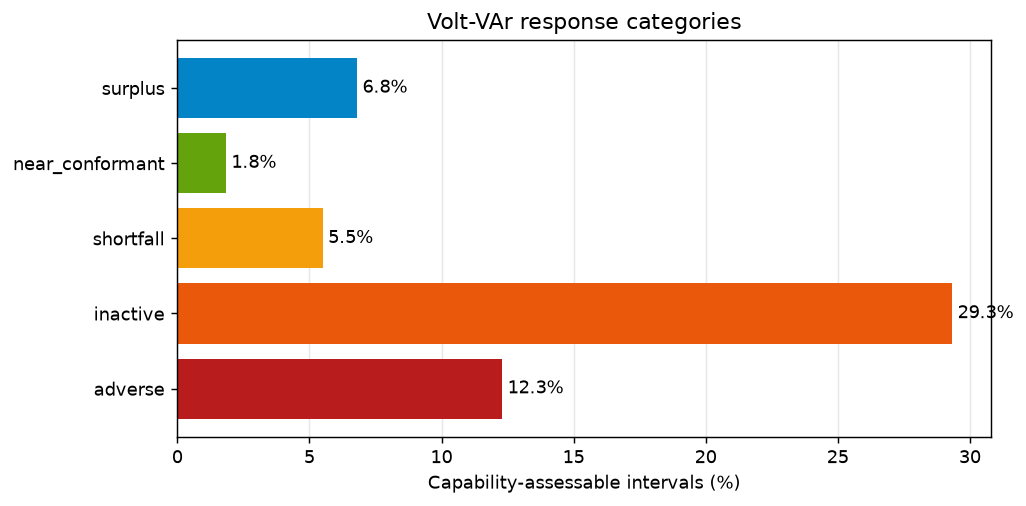

In [10]:
vvar_site_year = cq.fetch_vvar_site_year(aq, CONFIG)
vvar_sites = cm.prepare_vvar_conformance(vvar_site_year, CONFIG)
vvar_result = cm.fleet_result(
    vvar_sites, 'Volt-VAr capability-conditioned conformance',
    'Was measured Q within the required and capability-clamped band?',
    'capability-assessable intervals',
)
vvar_bands = cm.vvar_band_summary(vvar_site_year)
vvar_energy_site_year, vvar_energy_summary = cm.vvar_curtailment_summary(
    vvar_site_year, CONFIG.interval_h)
display(vvar_result)
display(vvar_bands)
display(vvar_energy_summary)
cp.plot_vvar_bands(vvar_bands);

## 6. State, DNSP, OEM, installation-year and time breakdowns


Volt-Watt by state


,state,n_sites,denominator_intervals,nonconforming_intervals,fleet_conformant_pct,fleet_any_nonconf_pct,interval_nonconf_pct
3,QLD,1867,2960902,607949,76.700589,38.243171,20.532561
5,TAS,72,47559,359,84.722222,30.555556,0.754852
2,NT,68,78623,4380,88.235294,27.941176,5.570889
1,NSW,1825,2634620,195518,89.150685,23.452055,7.421108
4,SA,309,284075,31545,89.644013,23.624595,11.104462
7,WA,161,230213,21873,90.062112,18.63354,9.501201
0,ACT,78,47228,4558,92.307692,17.948718,9.651054
6,VIC,429,288705,1901,95.337995,13.752914,0.658458



Volt-Watt by dnsp


,dnsp,n_sites,denominator_intervals,nonconforming_intervals,fleet_conformant_pct,fleet_any_nonconf_pct,interval_nonconf_pct
6,Ergon,1258,2764397,590349,76.709062,38.63275,21.355435
5,Energex,563,275375,25208,76.731794,36.412078,9.154063
12,TasNetworks,68,47230,357,85.294118,29.411765,0.755876
7,Essential,605,1007865,91687,86.61157,28.92562,9.097151
1,Ausgrid,830,1289952,90513,88.433735,23.73494,7.016773
11,SAPN,301,272428,30671,90.033223,22.591362,11.258388
13,Unknown,193,180286,14116,90.15544,22.797927,7.829782
14,Western Power,33,16643,976,90.909091,12.121212,5.864327
4,Endeavour,445,384346,17724,91.685393,19.325843,4.61147
0,Actewagl,78,47228,4558,92.307692,17.948718,9.651054



Volt-Watt by oem


...

,install_year,n_sites,denominator_intervals,nonconforming_intervals,fleet_conformant_pct,fleet_any_nonconf_pct,interval_nonconf_pct
4,2011,20,690130,424126,15.0,100.0,61.455958
11,2018,642,22348285,13400701,17.912773,97.819315,59.962995
12,2019,1758,55972900,33511321,17.918089,98.464164,59.870618
7,2014,33,1253525,777932,18.181818,100.0,62.059552
9,2016,194,5588516,2969350,19.587629,96.907216,53.133068
13,2020,2834,125926852,71509234,20.924488,97.741708,56.786327
10,2017,315,10463684,5759541,20.952381,98.412698,55.043147
18,2025,1047,17591373,9213071,24.546323,92.359121,52.372666
14,2021,2641,127180826,67488444,25.937145,97.652404,53.064952
8,2015,92,2913895,1638717,27.173913,94.565217,56.238025



Volt-Watt curtailed energy by DNSP


,dnsp,n_sites,sites_with_curtailment,curtailed_kwh,median_site_kwh
6,Ergon,393,393,4179.820420,0.821939
7,Essential,181,181,1353.427048,0.632612
1,Ausgrid,236,236,986.745902,0.464578
4,Endeavour,75,75,458.391794,0.704784
5,Energex,97,97,354.320631,0.506215
11,SAPN,75,75,300.015952,0.355713
13,Unknown,50,50,173.690444,0.818138
10,Powercor,28,28,104.096968,0.651842
2,Ausnet,31,31,53.836524,0.618116



Volt-VAr curtailed energy by DNSP


,dnsp,n_sites,sites_with_curtailment,curtailed_kwh,median_site_kwh
7,Essential,1483,205,38.711122,0.0
6,Ergon,3287,425,37.664001,0.0
5,Energex,2446,329,26.787693,0.0
1,Ausgrid,2716,301,20.111751,0.0
13,TasNetworks,353,91,7.778984,0.0
4,Endeavour,1965,132,7.104454,0.0
2,Ausnet,407,50,6.115152,0.0
11,Powercor,414,57,5.631336,0.0
12,SAPN,1218,44,2.346353,0.0
9,Jemena,130,17,2.178410,0.0


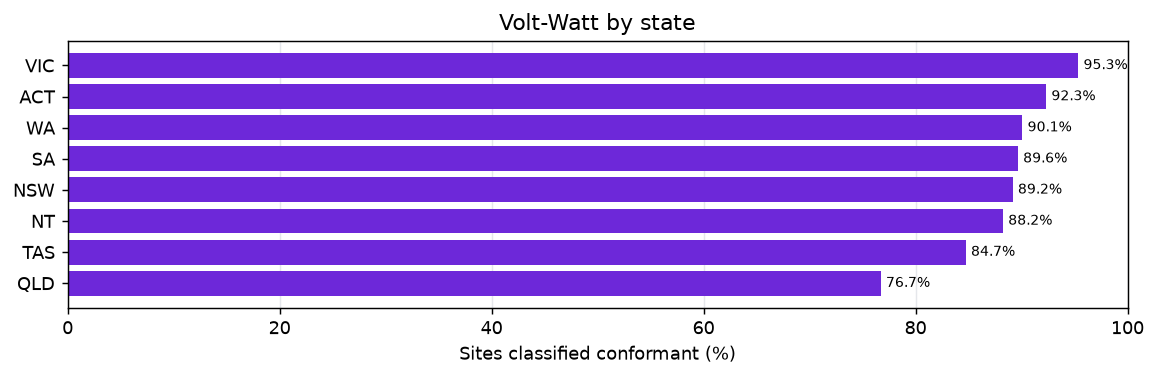

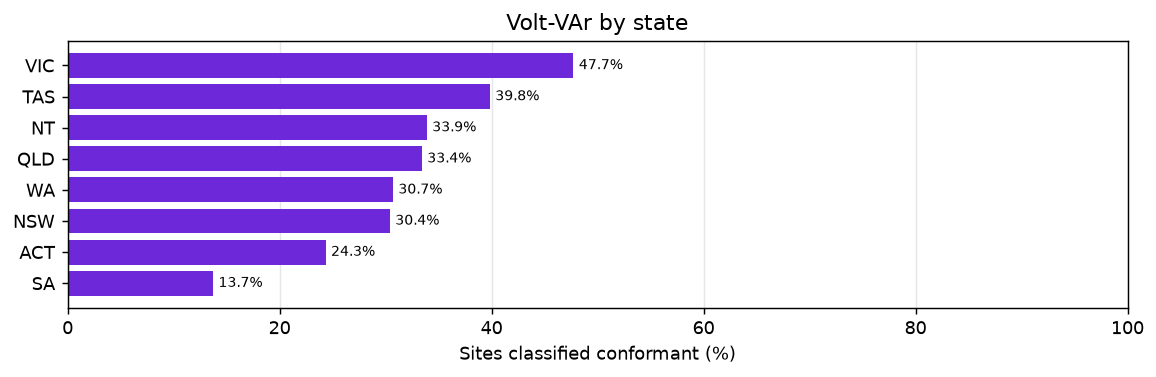

In [11]:
breakdowns = {}
for mechanism, frame in [('Volt-Watt', vw_sites), ('Volt-VAr', vvar_sites)]:
    for group in ('state', 'dnsp', 'oem', 'install_year'):
        key = (mechanism, group)
        breakdowns[key] = cm.group_breakdown(frame, meta, group, min_sites=20)
        print(f'\n{mechanism} by {group}')
        display(breakdowns[key])

cp.plot_group_breakdown(breakdowns[('Volt-Watt','state')], 'state', 'Volt-Watt by state')
cp.plot_group_breakdown(breakdowns[('Volt-VAr','state')], 'state', 'Volt-VAr by state')

vw_energy_breakdowns = {g: cm.energy_group_breakdown(vw_energy_sites, meta, g, min_sites=20)
                        for g in ('state','dnsp','oem','install_year')}
vvar_energy_breakdowns = {g: cm.energy_group_breakdown(vvar_energy_site_year, meta, g, min_sites=20)
                          for g in ('state','dnsp','oem','install_year')}
print('\nVolt-Watt curtailed energy by DNSP')
display(vw_energy_breakdowns['dnsp'])
print('\nVolt-VAr curtailed energy by DNSP')
display(vvar_energy_breakdowns['dnsp'])

,year,month,n_sites,nonconf_count,denominator_count,interval_nonconf_pct,period
0,2024,1,1459,34375,256125,13.421181,2024-01-01
1,2024,2,1549,33674,253862,13.264687,2024-02-01
2,2024,3,1504,33945,277300,12.241255,2024-03-01
3,2024,4,1508,32468,317213,10.235394,2024-04-01
4,2024,5,1418,18893,241203,7.832821,2024-05-01
5,2024,6,1291,23425,254323,9.210728,2024-06-01
6,2024,7,1318,25643,263441,9.733868,2024-07-01
7,2024,8,1583,45287,357396,12.671379,2024-08-01
8,2024,9,1633,60278,424852,14.188,2024-09-01
9,2024,10,1648,87885,479926,18.312198,2024-10-01


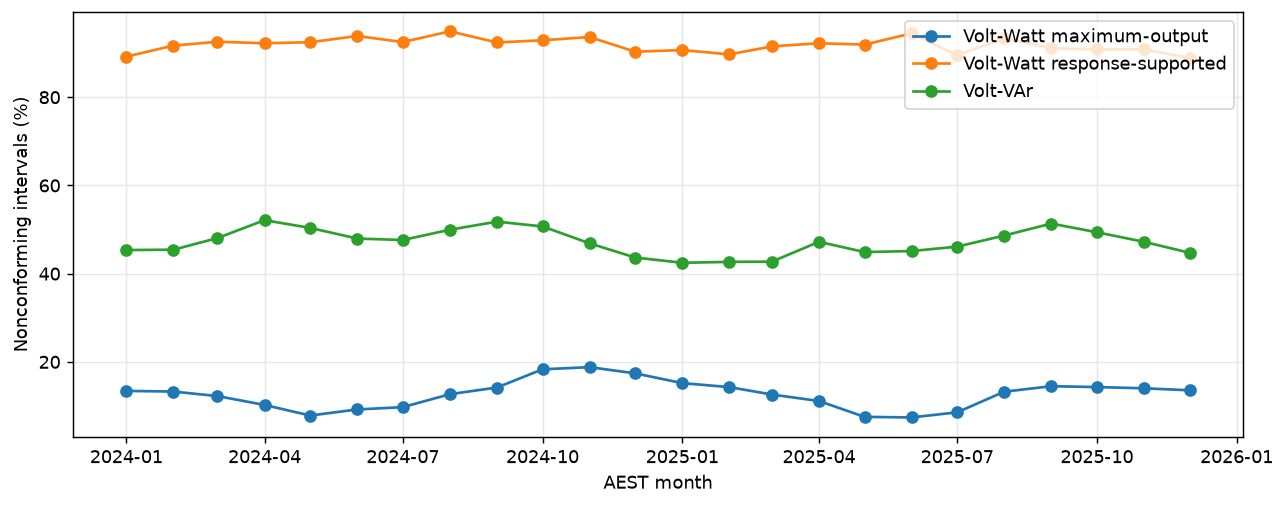

In [12]:
monthly_vw = cm.monthly_rates(cq.fetch_monthly_fleet(aq, CONFIG, 'vw'))
monthly_vwg = cm.monthly_rates(cq.fetch_monthly_fleet(aq, CONFIG, 'vw_response'))
monthly_vvar = cm.monthly_rates(cq.fetch_monthly_fleet(aq, CONFIG, 'vvar'))
display(monthly_vw)
cp.plot_monthly_rates(('Volt-Watt maximum-output', monthly_vw),
                      ('Volt-Watt response-supported', monthly_vwg),
                      ('Volt-VAr', monthly_vvar));

## 7. Legacy reconciliation and reporting-ready tally

In [13]:
legacy_by_year = cq.fetch_legacy_population_by_year(aq, CONFIG)
legacy_membership = cq.fetch_original_v2_membership(aq, CONFIG)
display(legacy_by_year)
display(legacy_membership)
print('Do not add yearly site counts: sites can appear in both years.')

,year,voltage_exposed_sites,review_corrected_sites,legacy_like_sites
0,2024,3525,1268,2667
1,2025,3338,1306,2358


,cohort,n_sites
0,original_basic,5021
1,original_ghi,5021
2,v2_basic,15609
3,v2_ghi_counterfactual_present,3500
4,v2_ghi_response_supported,1878


Do not add yearly site counts: sites can appear in both years.


,metric,question,denominator,n_sites,n_intervals,n_nonconforming_intervals,interval_nonconf_pct,fleet_conformant_pct,fleet_any_nonconf_pct
0,Volt-Watt maximum-output conformance,Did measured P exceed the voltage-dependent ma...,voltage-exposed intervals (V > 253 V),4809,6571925,868083,13.208961,84.903306,28.259513
1,Volt-Watt response-supported result,Was enough solar power available to test the r...,response-supported intervals,1878,944752,868083,91.884749,32.002130,72.364217
2,Volt-VAr capability-conditioned conformance,Was measured Q within the required and capabil...,capability-assessable intervals,15609,624116619,294154553,47.131344,31.847011,95.778077


,result,question_answered,principal_limitation
0,Volt-Watt maximum-output,Primary standards-oriented maximum-output test,Counterfactual not required; below ceiling doe...
1,Volt-Watt response-supported,Evidence that the response had an opportunity ...,Narrower GHI-supported population; not the pri...
2,Volt-Watt curtailed energy,Estimated generation displaced,Only counterfactual-covered intervals
3,Volt-VAr conformance,Required Q conditional on implemented capabili...,S_rated is proxied by the recorded rating basis
4,Volt-VAr curtailment,Headline only here; causal evidence is in note...,"S_99 is empirical, not verified manufacturer S..."


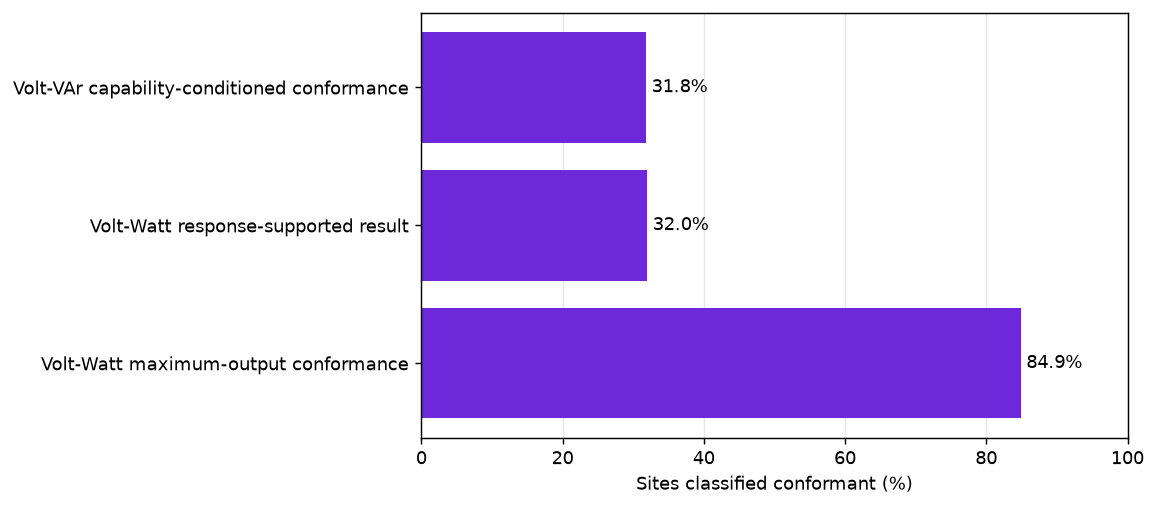

In [14]:
headline_results = cm.reporting_tally(vw_result, vwg_result, vvar_result)
display(headline_results)
cp.plot_fleet_summary(headline_results);

reporting_notes = pd.DataFrame([
    ['Volt-Watt maximum-output', 'Primary standards-oriented maximum-output test', 'Counterfactual not required; below ceiling does not prove active response'],
    ['Volt-Watt response-supported', 'Evidence that the response had an opportunity to operate', 'Narrower GHI-supported population; not the primary compliance denominator'],
    ['Volt-Watt curtailed energy', 'Estimated generation displaced', 'Only counterfactual-covered intervals'],
    ['Volt-VAr conformance', 'Required Q conditional on implemented capability floor', 'S_rated is proxied by the recorded rating basis'],
    ['Volt-VAr curtailment', 'Headline only here; causal evidence is in notebook 03', 'S_99 is empirical, not verified manufacturer S_rated'],
], columns=['result', 'question_answered', 'principal_limitation'])
display(reporting_notes)